<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE338/blob/main/LAB/LAB2/lab2_spatial_analysis_6606520168_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install geopandas rasterio folium geemap earthengine-api shapely pyproj fiona rtree rasterstats -q

In [10]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt
import folium
import numpy as np
import ee
import geemap
import pandas as pd
from rasterstats import zonal_stats


In [11]:
ee.Authenticate()
ee.Initialize(project='ee-pondpatipatpankaew')

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# =========================
# 2️⃣ Load Raster & Shapefile
# =========================
tif_path = '/content/drive/MyDrive/GE338/Data/TAK.tif'
shp_path = '/content/drive/MyDrive/GE338/Data/prov_ตาก.shp'

In [14]:
# Load raster
src = rasterio.open(tif_path)
print("จำนวน band:", src.count)

# Load shapefile (จังหวัด/อำเภอ)
gdf = gpd.read_file(shp_path)
print("Raster CRS:", src.crs)
print("Shapefile CRS:", gdf.crs)

gdf = gdf.to_crs(src.crs)

จำนวน band: 12
Raster CRS: EPSG:32647
Shapefile CRS: EPSG:32647


In [15]:
# =========================
# 3️⃣ Clip Raster ด้วย Shape
# =========================
geoms = [geom for geom in gdf.geometry]
out_img, out_transform = mask(src, geoms, crop=True)


In [16]:
# แยก Band หลัง Clip
blue_c  = out_img[1].astype('float32')
green_c = out_img[2].astype('float32')
red_c   = out_img[3].astype('float32')
nir_c   = out_img[7].astype('float32')

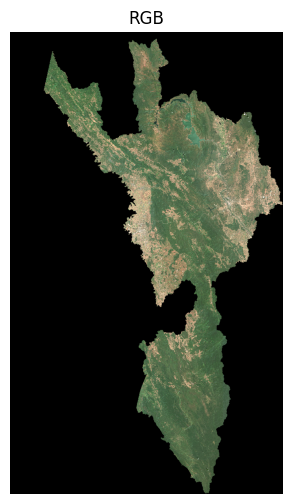

In [17]:
# =========================
# 4️⃣ สร้าง RGB สำหรับ Visualization
# =========================
rgb = np.stack([red_c, green_c, blue_c], axis=-1).astype('float32')
# Normalize
rgb = rgb / 10000.0

# Gamma correction
rgb = np.power(rgb, 1/1.6)

# Plot RGB
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB")
plt.axis('off')
plt.show()

In [18]:
# =========================
# 5️⃣ NDVI & NDWI
# =========================
ndvi = (nir_c - red_c) / (nir_c + red_c + 1e-6)
ndwi = (green_c - nir_c) / (green_c + nir_c + 1e-6)


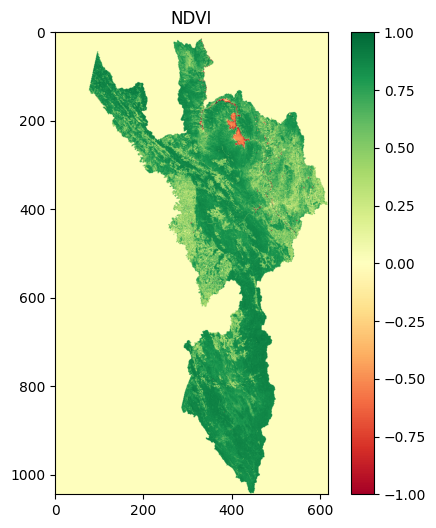

In [19]:
# NDVI Visualization
plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar()
plt.title("NDVI")
plt.show()

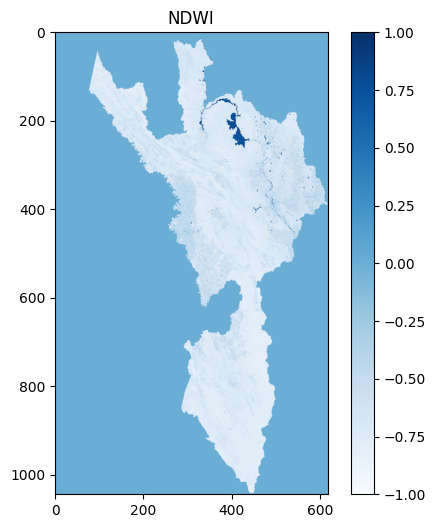

In [20]:
# NDWI Visualization
plt.figure(figsize=(6,6))
plt.imshow(ndwi, cmap='Blues', vmin=-1, vmax=1)
plt.colorbar()
plt.title("NDWI")
plt.show()

In [21]:
# =========================
# 6️⃣ คำนวณพื้นที่ (km²) ของป่าและน้ำ
# =========================
pixel_area = src.res[0] * src.res[1]  # m²

forest = ndvi > 0.5
forest_area = np.nansum(forest) * pixel_area / 1e6
print("Forest area (km²):", forest_area)

water = ndwi > 0.2
water_area = np.nansum(water) * pixel_area / 1e6
print("Water area (km²):", water_area)


Forest area (km²): 14299.037108404704
Water area (km²): 158.735923210641


In [22]:
shp_district_path = '/content/drive/MyDrive/GE338/Data/amp_ตาก.shp'
gdf_district = gpd.read_file(shp_district_path)

# แปลง CRS ให้ตรงกับ raster
gdf_district = gdf_district.to_crs(src.crs)


In [23]:
# =========================
# Zonal Statistics ต่ออำเภอ
# =========================
# ฟังก์ชัน zonal stats
def zonal_stats(raster, gdf, transform):
    stats_list = []
    for geom in gdf.geometry:
        # mask พื้นที่ polygon
        out_image, out_transform = mask(src, [geom], crop=True)
        out_image = out_image.astype('float32')
        # normalize หาก raster ยังไม่ได้ normalize
        arr = out_image[0]  # ใช้ band เดียว
        arr = arr.astype('float32')
        arr[arr == src.nodata] = np.nan
        mean_val = np.nanmean(arr)
        stats_list.append({'mean': mean_val})
    return stats_list

# คำนวณ Zonal Stats
ndvi_stats_district = zonal_stats(ndvi, gdf_district, out_transform)
ndwi_stats_district = zonal_stats(ndwi, gdf_district, out_transform)


In [24]:
# =========================
# Merge stats กลับไปที่ gdf อำเภอ
# =========================
ndvi_stats_df = pd.DataFrame(ndvi_stats_district)
ndvi_stats_df['AMPHOE_T'] = gdf_district['AMPHOE_T']

ndwi_stats_df = pd.DataFrame(ndwi_stats_district)
ndwi_stats_df['AMPHOE_T'] = gdf_district['AMPHOE_T']

gdf_ndvi_district = gdf_district.merge(ndvi_stats_df, on='AMPHOE_T')
gdf_ndwi_district = gdf_district.merge(ndwi_stats_df, on='AMPHOE_T')


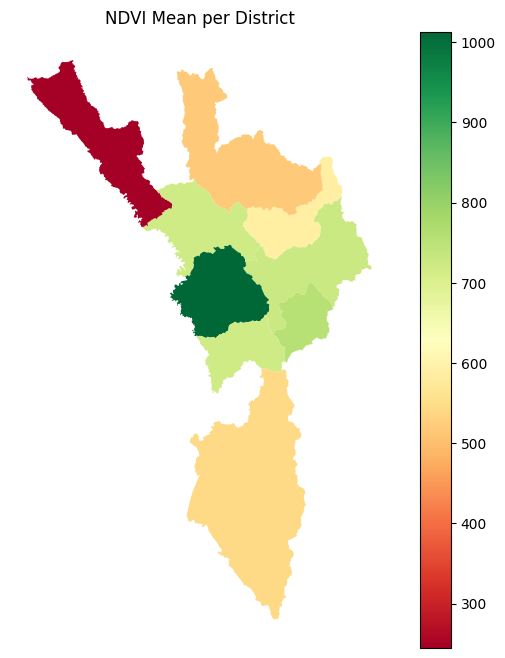

In [25]:
# =========================
# Plot NDVI per district
# =========================
gdf_ndvi_district.plot(column='mean', cmap='RdYlGn', legend=True, figsize=(8,8))
plt.title("NDVI Mean per District")
plt.axis('off')
plt.show()

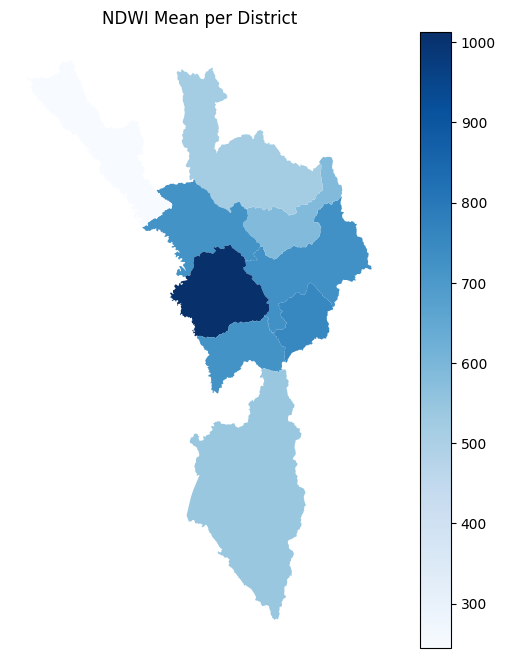

In [26]:
# =========================
# Plot NDWI per district
# =========================
gdf_ndwi_district.plot(column='mean', cmap='Blues', legend=True, figsize=(8,8))
plt.title("NDWI Mean per District")
plt.axis('off')
plt.show()

<Figure size 800x800 with 0 Axes>

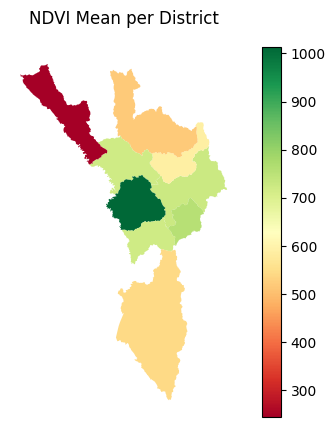

<Figure size 800x800 with 0 Axes>

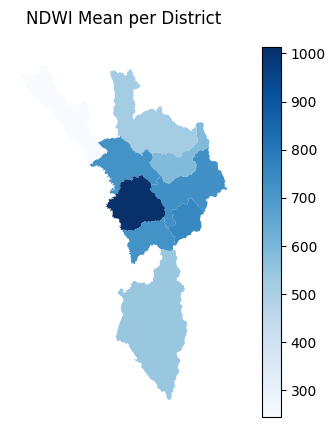

In [27]:
plt.figure(figsize=(8,8))
gdf_ndvi_district.plot(column='mean', cmap='RdYlGn', legend=True)
plt.title("NDVI Mean per District")
plt.axis('off')
plt.show()

plt.figure(figsize=(8,8))
gdf_ndwi_district.plot(column='mean', cmap='Blues', legend=True)
plt.title("NDWI Mean per District")
plt.axis('off')
plt.show()

In [29]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

figures_dir = '/content/drive/MyDrive/GE338/figures'
os.makedirs(figures_dir, exist_ok=True)

# =========================
# NDVI Map
# =========================
fig, ax = plt.subplots(figsize=(8,8))
gdf_ndvi_district.plot(column='mean', cmap='RdYlGn', legend=True, ax=ax, edgecolor='black', linewidth=0.8)
ax.set_title("NDVI Mean per District")
ax.axis('off')

# Export NDVI PNG
ndvi_png_path = os.path.join(figures_dir, 'ndvi_district_border.png')
plt.savefig(ndvi_png_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print("Exported NDVI map with border to:", ndvi_png_path)

# =========================
# NDWI Map
# =========================
water_cmap = ListedColormap(["#cce6ff", "#66b3ff", "#0099ff", "#0066cc"])

fig, ax = plt.subplots(figsize=(8,8))
gdf_ndwi_district.plot(column='mean', cmap=water_cmap, legend=True, ax=ax, edgecolor='black', linewidth=0.8)
ax.set_title("NDWI Mean per District")
ax.axis('off')

# Export NDWI PNG
ndwi_png_path = os.path.join(figures_dir, 'ndwi_district_border.png')
plt.savefig(ndwi_png_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print("Exported NDWI map with blue tone and border to:", ndwi_png_path)

Exported NDVI map with border to: /content/drive/MyDrive/GE338/figures/ndvi_district_border.png
Exported NDWI map with blue tone and border to: /content/drive/MyDrive/GE338/figures/ndwi_district_border.png
